# Shear Profile of Abell 360 using AnaCal (Cell-based Coadds)

Xiangchong Li, Prakruth Adari, Anja von der Linden

**Pipeline**: `MeasureCoaddsPipe` on LSST Science Pipelines v30.0.4.rc1

**Steps**:
1. Load AnaCal catalogs from the butler
2. Sky coverage and mask visualization
3. Magnitude histograms and band weights
4. Color selection to remove red-sequence cluster members
5. Shear estimation and tangential shear profile
6. Mass map (E-mode and B-mode)

## 1. Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy.stats as stats
from matplotlib import cm
from astropy.table import Table, vstack
from lsst.daf.butler import Butler
from lsst.geom import SpherePoint, Point2D, degrees as lsst_degrees
import clmm
from clmm import Cosmology, utils

# Cosmology
cosmo = clmm.Cosmology(H0=70.0, Omega_dm0=0.3 - 0.045, Omega_b0=0.045, Omega_k0=0.0)
z_cl = 0.22

# Cosmological distances
H0, c_light = 70.0, 3e5
omega_m, omega_de = 0.31, 0.69
Hz = lambda z: c_light / (H0 * np.sqrt(omega_de + omega_m * (1 + z)**3))
chi_dl = lambda z, z0=0: integrate.quad(Hz, z0, z)[0]
Da = lambda z: chi_dl(z) / (1 + z)

# Source redshift distribution (DESC SRD)
z_distrib_func = utils.redshift_distributions.desc_srd
beta_kwargs = {"z_cl": z_cl, "z_inf": 10.0, "cosmo": cosmo, "z_distrib_func": z_distrib_func}
beta_s_mean = utils.compute_beta_s_mean_from_distribution(**beta_kwargs)
beta_s_square_mean = utils.compute_beta_s_square_mean_from_distribution(**beta_kwargs)
rproj = np.logspace(np.log10(0.3), np.log10(7.0), 100)

## 2. Load Data

In [2]:
# Butler setup
butler_config = "/global/cfs/cdirs/lsst/production/gen3/rubin/DP1/repo/butler.yaml"
# This notebook works on the per-patch (pre-merge) AnaCal catalog
# ``deep_coadd_anacal_catalog`` produced by ``MeasureCoaddsPipe``
# and stacks/combines the bands locally. The per-tract merged catalog
# ``deep_coadd_anacal_merged`` (output of ``MergePipe``)
# is NOT used here.
anacal_collection = "u/xiangchl/dp1/a360_anacal_coadd/20260513T081515Z"
input_collections = [
    anacal_collection,
    "u/mgorsuch/metadetect/a360_extra_cells",
    "u/mgorsuch/metadetect/a360_metadetect",
    "u/mgorsuch/metadetect/a360_coadd",
    "LSSTComCam/DP1",
]
obs_butler = Butler(butler_config, collections=input_collections)
t_skymap = obs_butler.get("skyMap", skymap="lsst_cells_v1")

# Cluster and patch selection
cluster_coords = (37.865017, 6.982205)
ra_bcg, dec_bcg = cluster_coords
delta = 0.5
radec = [SpherePoint(ra_bcg + dx, dec_bcg + dy, lsst_degrees)
         for dx in [-delta, delta] for dy in [-delta, delta]]
tracts_and_patches = t_skymap.findTractPatchList(radec)
tp_dict = {}
for tract_num in range(len(tracts_and_patches)):
    tract_info = tracts_and_patches[tract_num][0]
    patches = [tracts_and_patches[tract_num][1][i].sequential_index
               for i in range(len(tracts_and_patches[tract_num][1]))]
    tp_dict[tract_info.getId()] = patches
print(tp_dict)

{10463: [30, 40, 50, 60, 70, 80, 90, 31, 41, 51, 61, 71, 81, 91, 32, 42, 52, 62, 72, 82, 92, 33, 43, 53, 63, 73, 83, 93, 34, 44, 54, 64, 74, 84, 94], 10704: [0, 1, 2, 3, 4, 5], 10464: [37, 47, 57, 67, 77, 87, 97, 38, 48, 58, 68, 78, 88, 98, 39, 49, 59, 69, 79, 89, 99], 10705: [8, 9]}


In [3]:
# Load per-patch (pre-merge) AnaCal catalogs from butler. These are the
# direct outputs of MeasureCoaddsPipe; the multi-band shapelet
# combination, photo-z join, and WCS distortion correction normally
# performed by MergePipe are reproduced inline below.
anacal_tables = []
mag_zero = 31.4
for tid in tp_dict:
    for p in tp_dict[tid]:
        try:
            refs = list(obs_butler.registry.queryDatasets(
                "deep_coadd_anacal_catalog",
                where=f"skymap='lsst_cells_v1' AND tract={tid} AND patch={p}",
                collections=[anacal_collection],
            ))
            if refs:
                anacal_tables.append(Table(obs_butler.get(refs[0])))
                print(f"Loaded tract={tid}, patch={p}: {len(anacal_tables[-1])} objects")
            else:
                print(f"No catalog for tract={tid}, patch={p}")
        except Exception as e:
            print(f"Failed tract={tid}, patch={p}: {e}")

anacal_table = vstack(anacal_tables)
print(f"\nTotal objects: {len(anacal_table)}")

# Compute magnitudes from flux_fpfs1 (m00-derived Gaussian-aperture flux,
# emitted by MeasureCoaddsPipe in the photoZPipe-compatible schema).
for band in ["g", "r", "i", "z"]:
    flux = anacal_table[f"{band}_flux_fpfs1"]
    valid = flux > 0
    anacal_table[f"{band}_mag"] = np.full(len(anacal_table), np.nan)
    anacal_table[f"{band}_mag"][valid] = mag_zero - np.log10(flux[valid]) * 2.5

Loaded tract=10463, patch=30: 3850 objects
Loaded tract=10463, patch=40: 4112 objects
Loaded tract=10463, patch=50: 3283 objects
Loaded tract=10463, patch=60: 3436 objects
Loaded tract=10463, patch=70: 3244 objects
Loaded tract=10463, patch=80: 3617 objects


Loaded tract=10463, patch=90: 8137 objects
Loaded tract=10463, patch=31: 3700 objects
Loaded tract=10463, patch=41: 3652 objects
Loaded tract=10463, patch=51: 3589 objects
Loaded tract=10463, patch=61: 4034 objects
Loaded tract=10463, patch=71: 3120 objects


Loaded tract=10463, patch=81: 3757 objects
Loaded tract=10463, patch=91: 4124 objects
Loaded tract=10463, patch=32: 3457 objects
Loaded tract=10463, patch=42: 2729 objects
Loaded tract=10463, patch=52: 3028 objects
Loaded tract=10463, patch=62: 3492 objects


Loaded tract=10463, patch=72: 3226 objects
Loaded tract=10463, patch=82: 3244 objects
Loaded tract=10463, patch=92: 3478 objects
Loaded tract=10463, patch=33: 3190 objects
Loaded tract=10463, patch=43: 3515 objects
Loaded tract=10463, patch=53: 3275 objects


Loaded tract=10463, patch=63: 2997 objects
Loaded tract=10463, patch=73: 3477 objects
Loaded tract=10463, patch=83: 3074 objects
Loaded tract=10463, patch=93: 3382 objects
Loaded tract=10463, patch=34: 1980 objects
Loaded tract=10463, patch=44: 3074 objects
Loaded tract=10463, patch=54: 3119 objects


...

Loaded tract=10464, patch=67: 3835 objects
Loaded tract=10464, patch=77: 3364 objects
Loaded tract=10464, patch=87: 3128 objects
Loaded tract=10464, patch=97: 3946 objects
Loaded tract=10464, patch=38: 3481 objects
Loaded tract=10464, patch=48: 4085 objects


Loaded tract=10464, patch=58: 3597 objects
Loaded tract=10464, patch=68: 3668 objects
Loaded tract=10464, patch=78: 3111 objects
Loaded tract=10464, patch=88: 3456 objects
Loaded tract=10464, patch=98: 3394 objects
Loaded tract=10464, patch=39: 3811 objects


Loaded tract=10464, patch=49: 3944 objects
Loaded tract=10464, patch=59: 3287 objects
Loaded tract=10464, patch=69: 3291 objects
Loaded tract=10464, patch=79: 3390 objects
Loaded tract=10464, patch=89: 3734 objects


Loaded tract=10464, patch=99: 7733 objects
No catalog for tract=10705, patch=8
No catalog for tract=10705, patch=9



Total objects: 227969


## 3. Sky Coverage and Mask

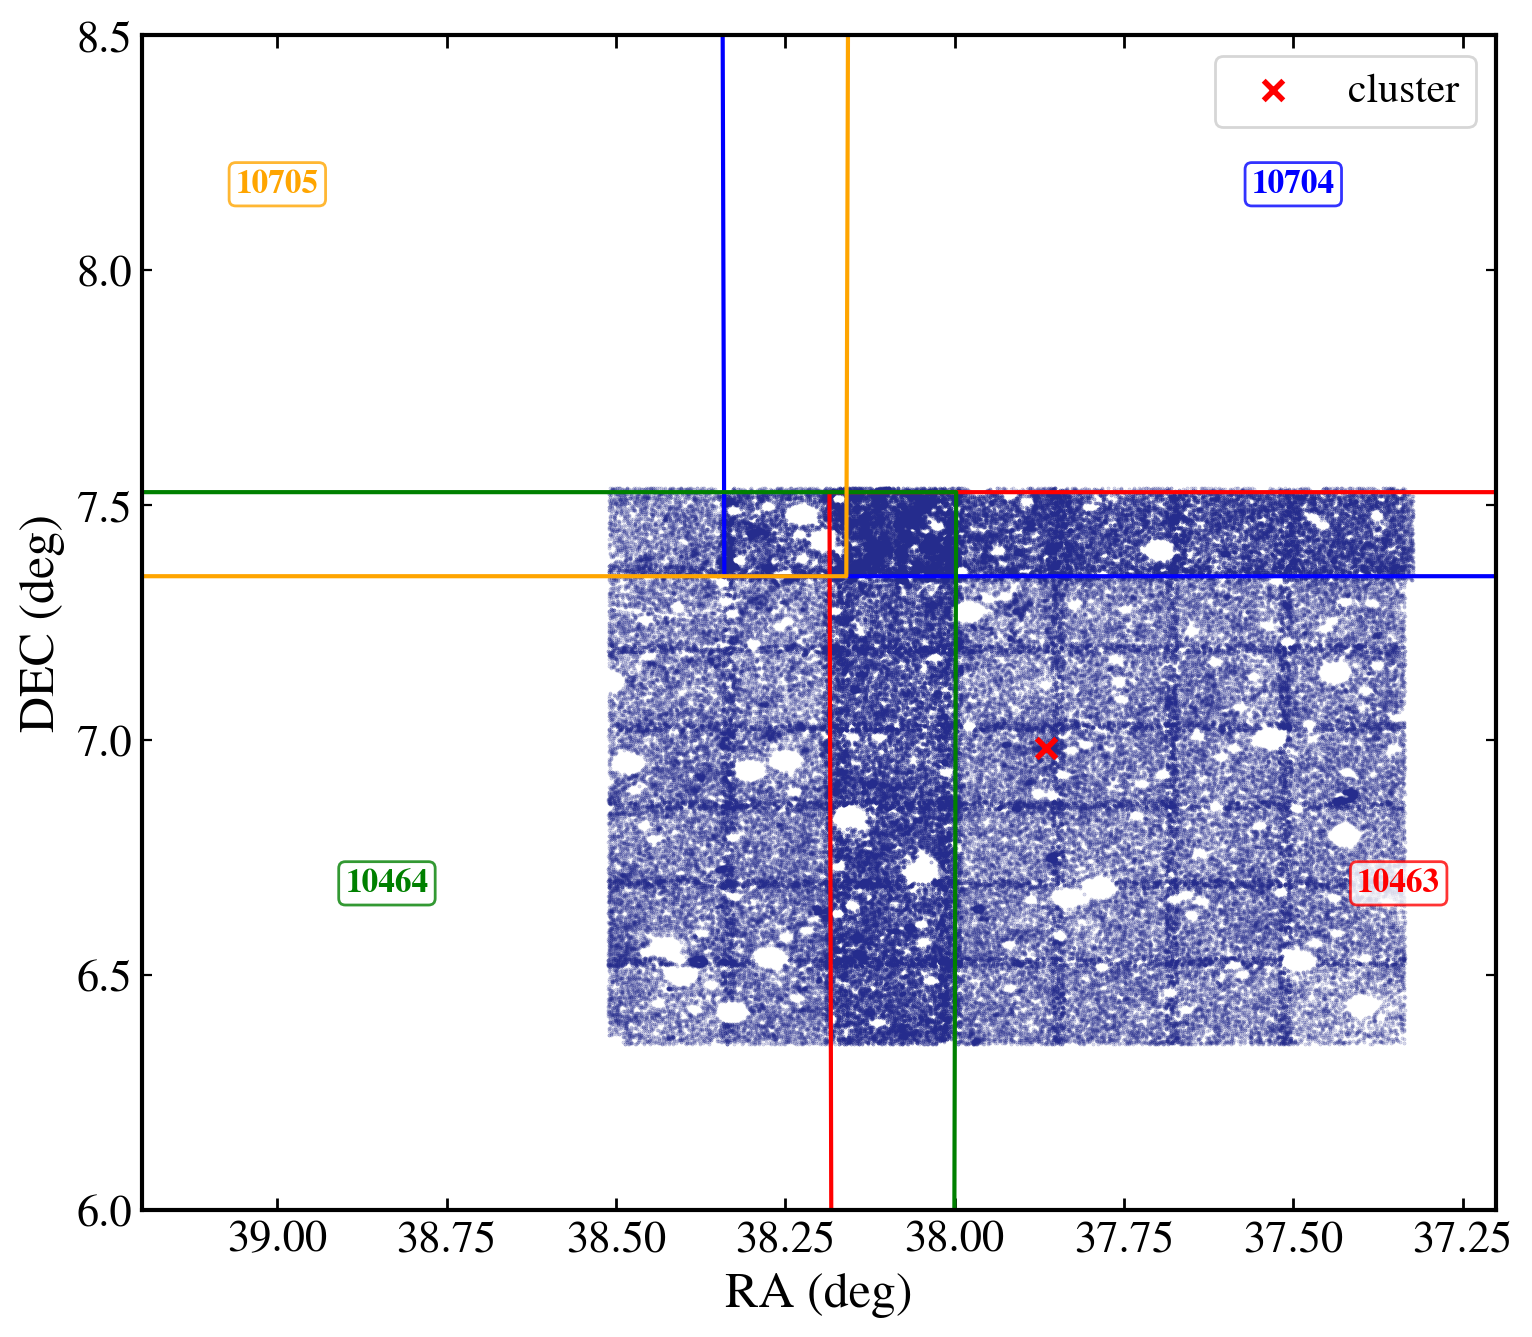

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(anacal_table["ra"], anacal_table["dec"], s=0.1, alpha=0.3)
ax.scatter(ra_bcg, dec_bcg, s=50, c='red', marker='x', zorder=10, label='cluster')

# Tract boundaries
tract_ids = [10463, 10704, 10464, 10705]
colors = ['red', 'blue', 'green', 'orange']
for tid, color in zip(tract_ids, colors):
    try:
        ti = t_skymap[tid]
        wcs = ti.getWcs()
        bb = ti.getBBox()
        corners = [(bb.getMinX(), bb.getMinY()), (bb.getMaxX(), bb.getMinY()),
                    (bb.getMaxX(), bb.getMaxY()), (bb.getMinX(), bb.getMaxY()),
                    (bb.getMinX(), bb.getMinY())]
        ra_c = [wcs.pixelToSky(Point2D(x, y)).getRa().asDegrees() for x, y in corners]
        dec_c = [wcs.pixelToSky(Point2D(x, y)).getDec().asDegrees() for x, y in corners]
        ax.plot(ra_c, dec_c, '-', color=color, lw=1.5)
        cen = wcs.pixelToSky(Point2D((bb.getMinX()+bb.getMaxX())/2, (bb.getMinY()+bb.getMaxY())/2))
        ax.text(cen.getRa().asDegrees(), cen.getDec().asDegrees(), str(tid),
                color=color, fontsize=12, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))
    except Exception:
        pass

ax.set_xlabel('RA (deg)'); ax.set_ylabel('DEC (deg)')
ax.set_xlim(37.2, 39.2)
ax.set_ylim(6, 8.5)
ax.legend(loc='upper right', fontsize=15)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

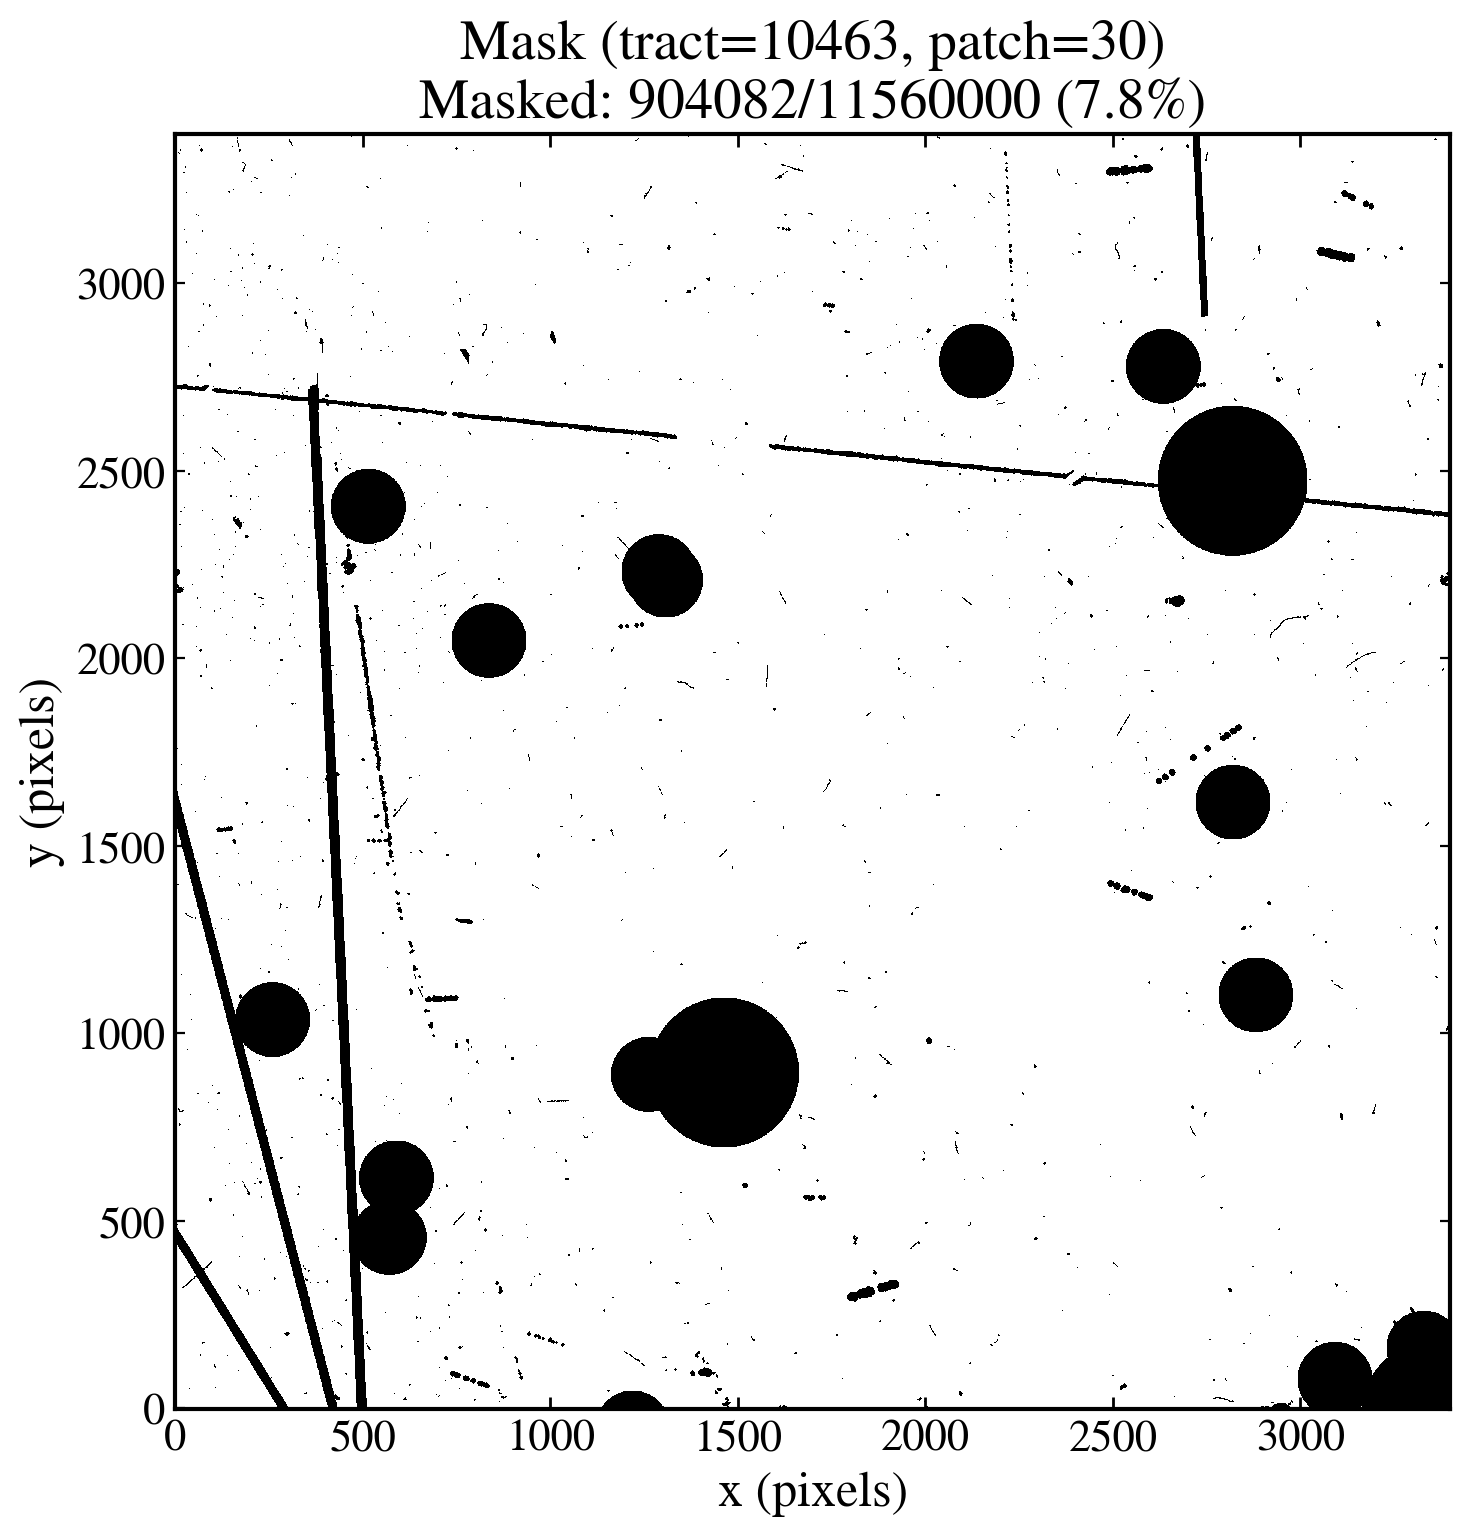

In [5]:
# Mask visualization (one patch)
test_tid = list(tp_dict.keys())[0]
test_pid = tp_dict[test_tid][0]
mask_refs = list(obs_butler.registry.queryDatasets(
    "deep_coadd_systematics_mask",
    where=f"skymap='lsst_cells_v1' AND tract={test_tid} AND patch={test_pid}",
    collections=[anacal_collection],
))
if mask_refs:
    mask_arr = obs_butler.get(mask_refs[0]).getArray()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(mask_arr, origin="lower", cmap="gray_r", interpolation="nearest")
    ax.set_title(f"Mask (tract={test_tid}, patch={test_pid})\n"
                 f"Masked: {np.sum(mask_arr != 0)}/{mask_arr.size} "
                 f"({100*np.sum(mask_arr != 0)/mask_arr.size:.1f}%)")
    ax.set_xlabel("x (pixels)"); ax.set_ylabel("y (pixels)")
    plt.tight_layout(); plt.show()
else:
    print(f"No mask for tract={test_tid}, patch={test_pid}")

## 4. Magnitude Distributions and Band Weights

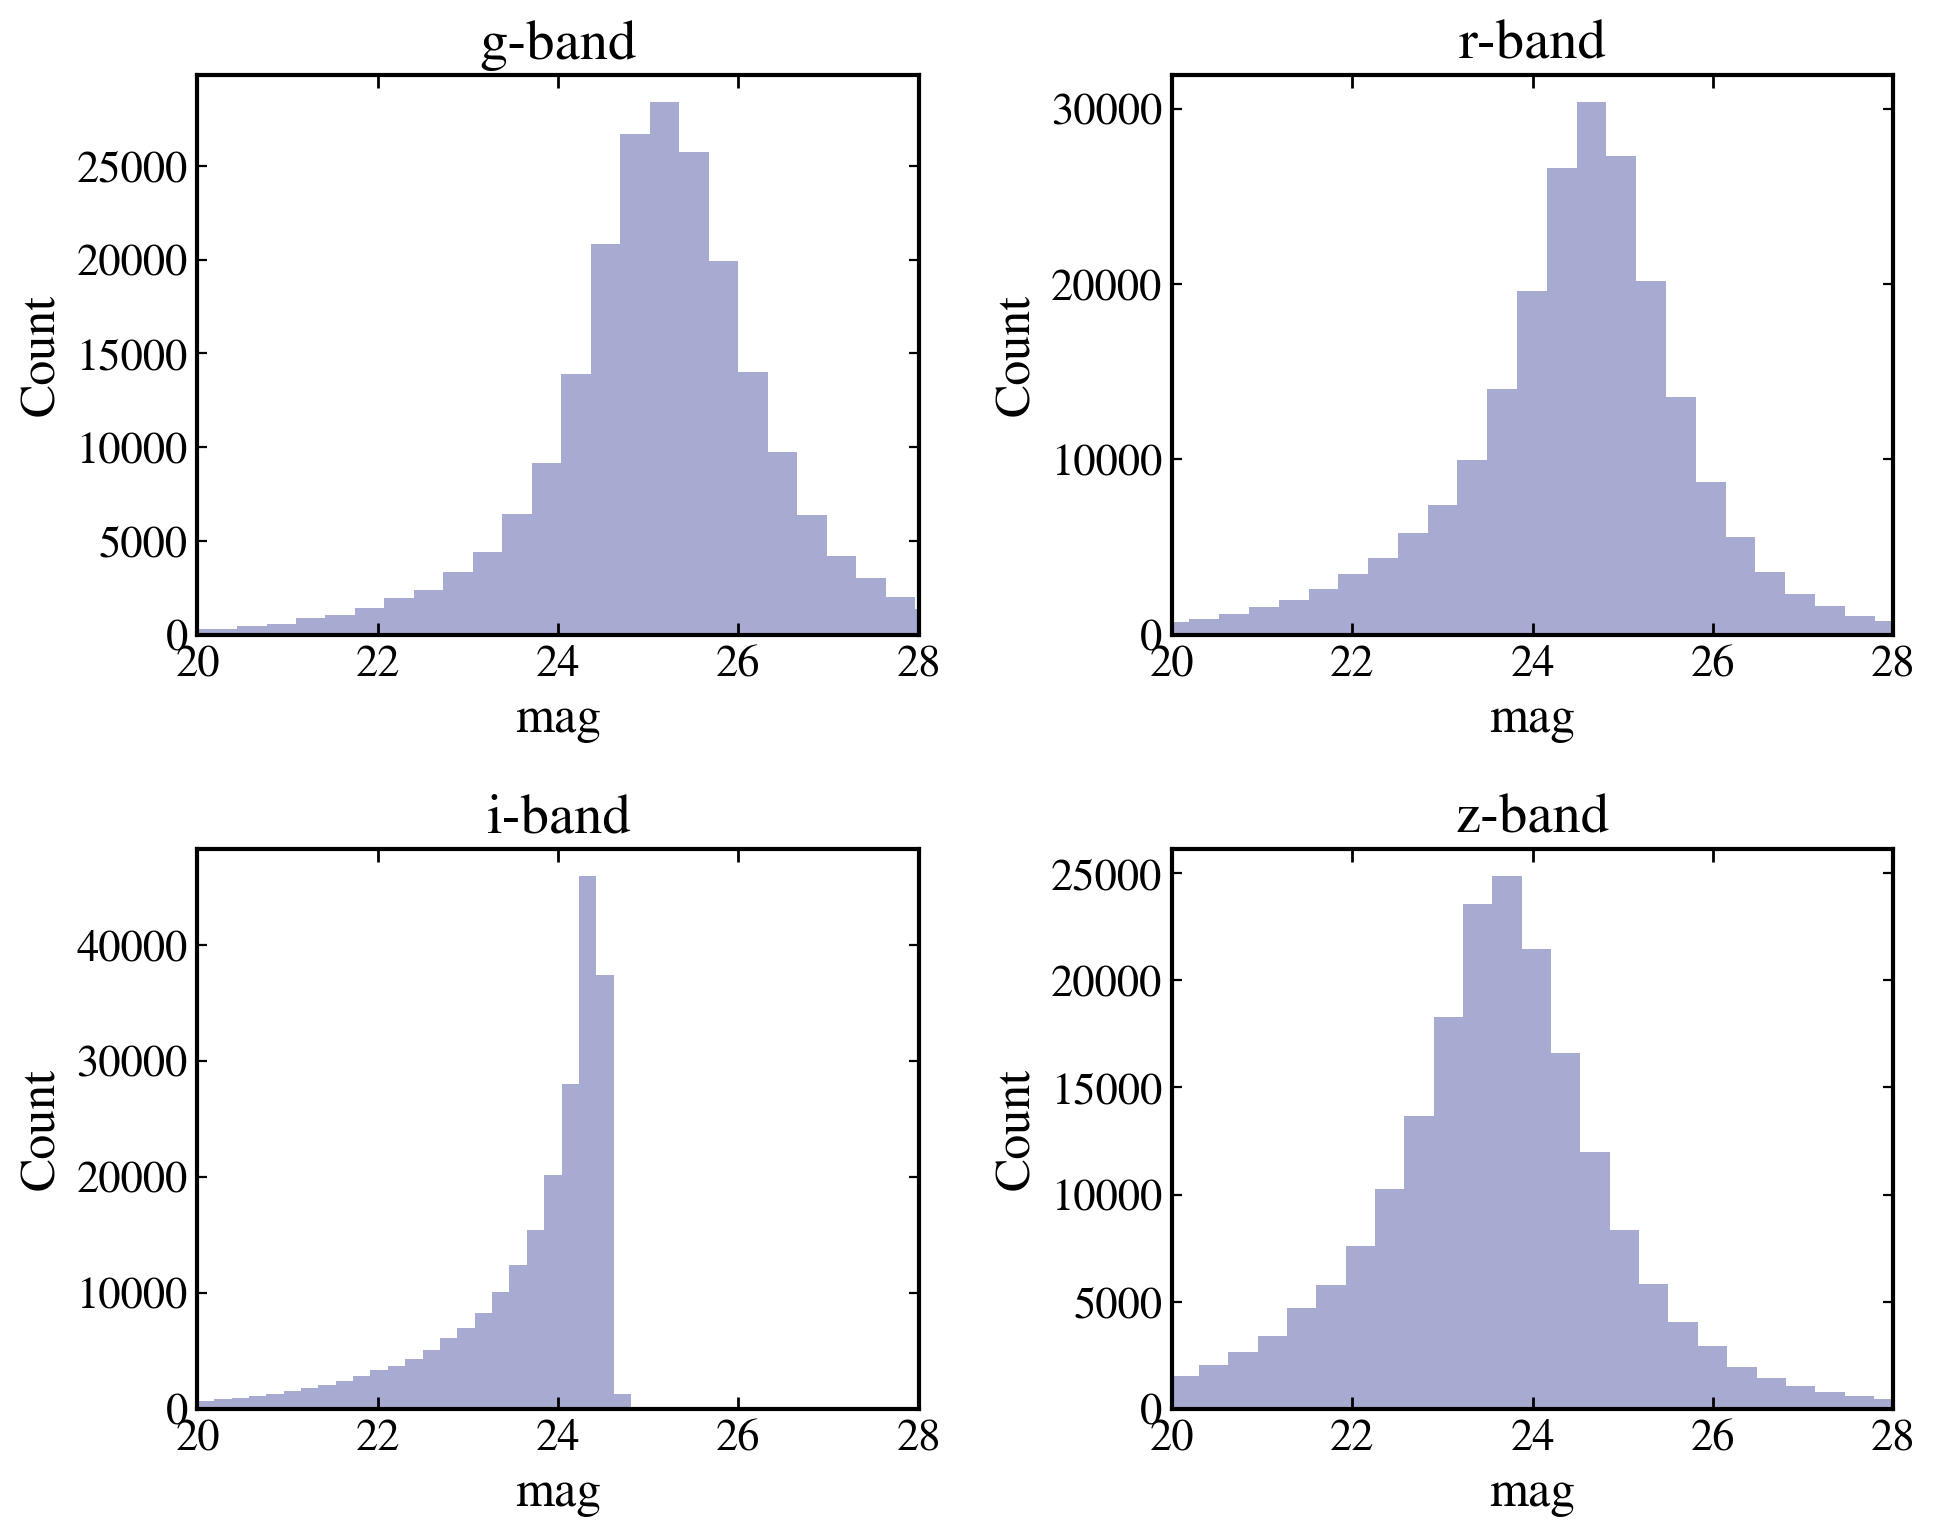

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, band in zip(axes.ravel(), ["g", "r", "i", "z"]):
    mag = anacal_table[f"{band}_mag"]
    mag = mag[np.isfinite(mag)]
    ax.hist(mag, bins=60, alpha=0.4)
    ax.set_title(f"{band}-band"); ax.set_xlabel("mag"); ax.set_ylabel("Count")
    ax.set_xlim(20, 28)
plt.tight_layout(); plt.show()

In [7]:
# Band weights from inverse variance of flux_fpfs1
wlist = np.array(
    [1.0 / np.median(anacal_table[f"{b}_flux_fpfs1_err"]) ** 2 for b in "griz"]
)
wlist /= wlist.sum()
print("Band weights (g, r, i, z):", dict(zip("griz", wlist)))

Band weights (g, r, i, z): {'g': np.float64(0.4845207005209397), 'r': np.float64(0.3158048965114066), 'i': np.float64(0.1874951901930564), 'z': np.float64(0.012179212774597135)}


## 5. Color Selection (Red-Sequence Removal)

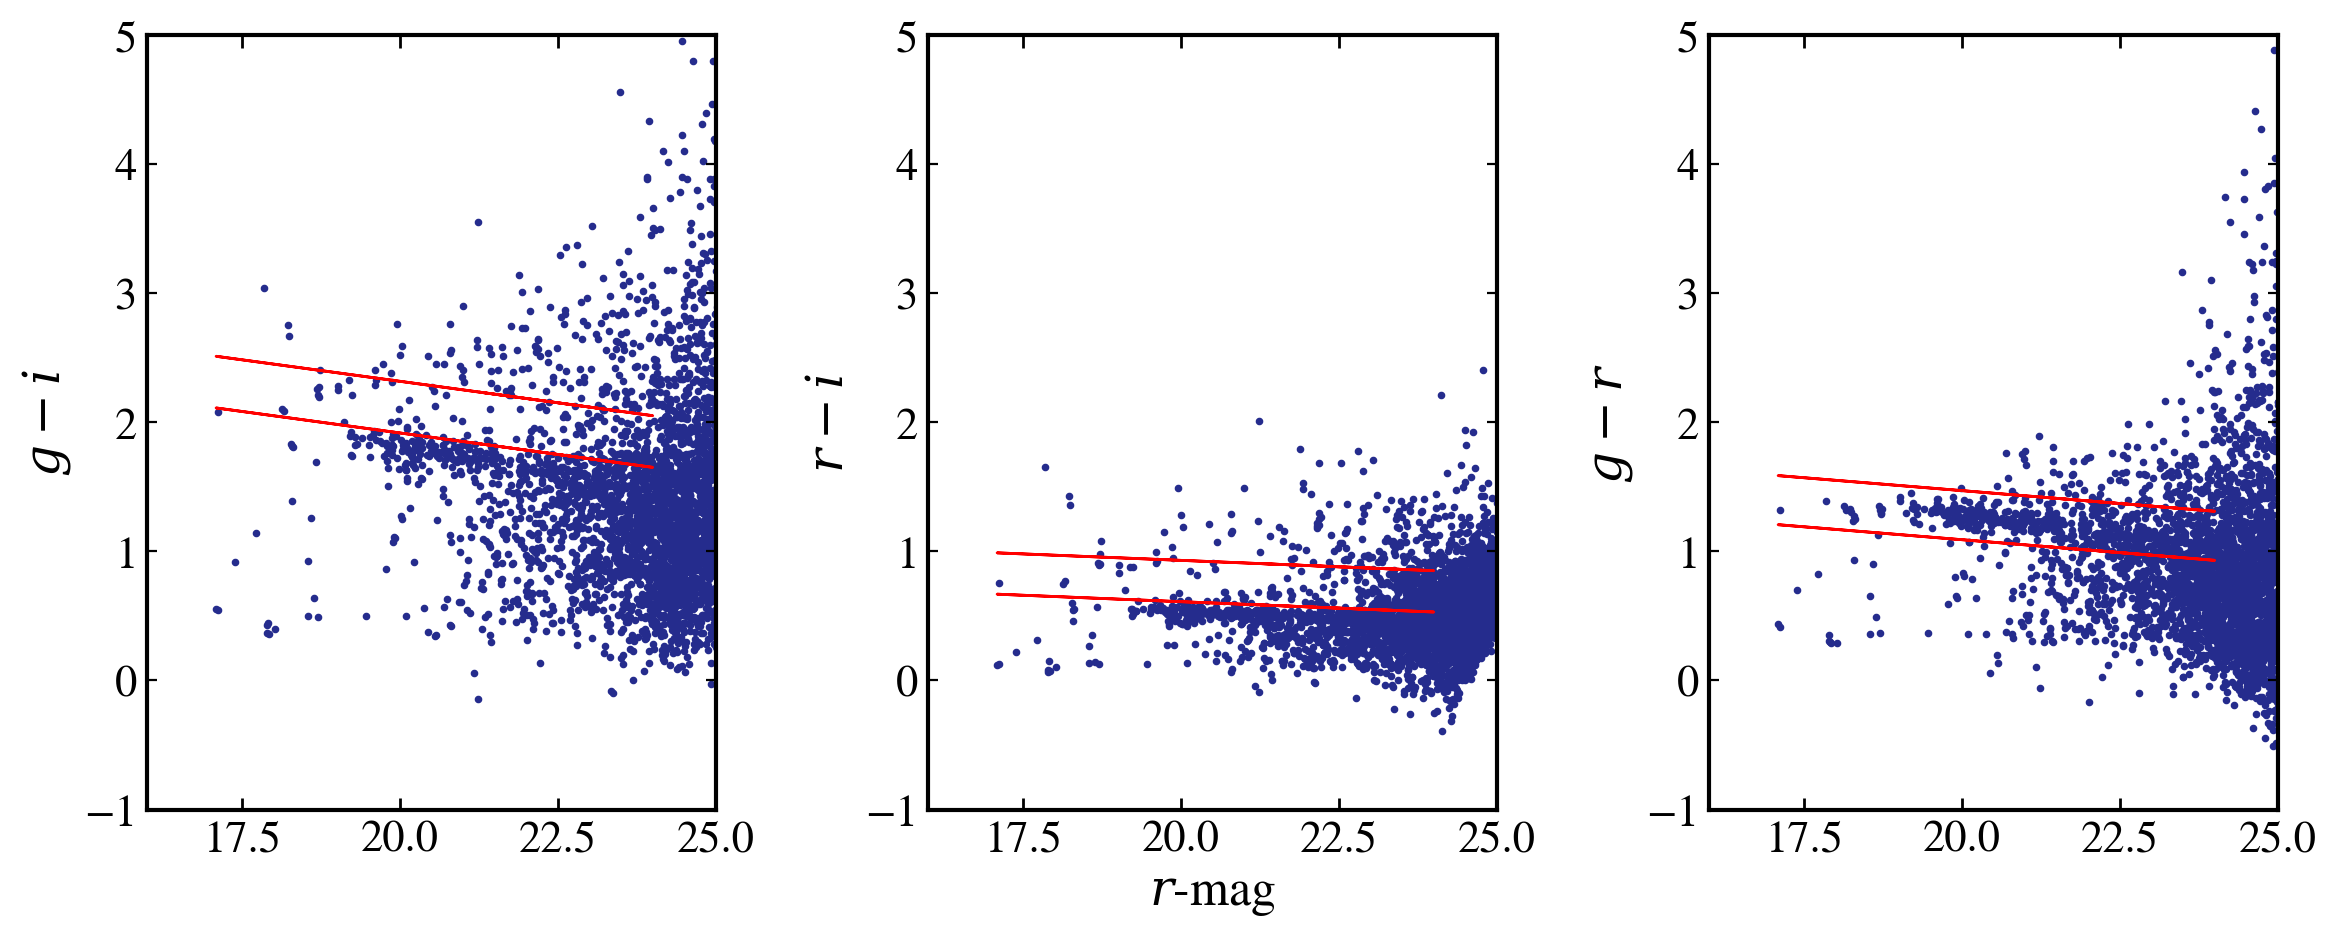

In [8]:
mag_lim = 24
gi_lims, ri_lims, gr_lims = (0.30, -0.10), (0.12, -0.20), (0.20, -0.18)
color_gi = anacal_table['g_mag'] - anacal_table['i_mag']
color_ri = anacal_table['r_mag'] - anacal_table['i_mag']
color_gr = anacal_table['g_mag'] - anacal_table['r_mag']
gi_line = (anacal_table['r_mag'] - 18) * (-0.20/3) + 2.15
ri_line = (anacal_table['r_mag'] - 18) * (-0.1/5) + .85
gr_line = (anacal_table['r_mag'] - 18) * (-0.12/3) + 1.35

gi_redseq = (color_gi < gi_line + gi_lims[0]) & (color_gi > gi_line + gi_lims[1]) & (anacal_table['r_mag'] < mag_lim)
ri_redseq = (color_ri < ri_line + ri_lims[0]) & (color_ri > ri_line + ri_lims[1]) & (anacal_table['r_mag'] < mag_lim)
gr_redseq = (color_gr < gr_line + gr_lims[0]) & (color_gr > gr_line + gr_lims[1]) & (anacal_table['r_mag'] < mag_lim)
counts = gi_redseq.astype(int) + ri_redseq.astype(int) + gr_redseq.astype(int)

dist = np.sqrt(((anacal_table['ra'] - ra_bcg) * np.cos(np.deg2rad(dec_bcg)))**2 + (anacal_table['dec'] - dec_bcg)**2)
mm = dist < 0.1
mag = anacal_table["r_mag"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharex=True)
for ax, col, line, lims, ylabel in zip(
    axes, [color_gi, color_ri, color_gr], [gi_line, ri_line, gr_line],
    [gi_lims, ri_lims, gr_lims], [r"$g - i$", r"$r - i$", r"$g - r$"]
):
    ax.scatter(mag[mm], col[mm], s=3.0)
    sel = mm & (mag < mag_lim)
    ax.plot(mag[sel], line[sel] + lims[0], 'r', lw=1)
    ax.plot(mag[sel], line[sel] + lims[1], 'r', lw=1)
    ax.set_ylabel(ylabel); ax.set_xlim(16, 25); ax.set_ylim(-1, 5)
axes[1].set_xlabel(r"$r$-mag")
plt.tight_layout(); plt.show()

Before cuts: 227969
After cuts:  43259


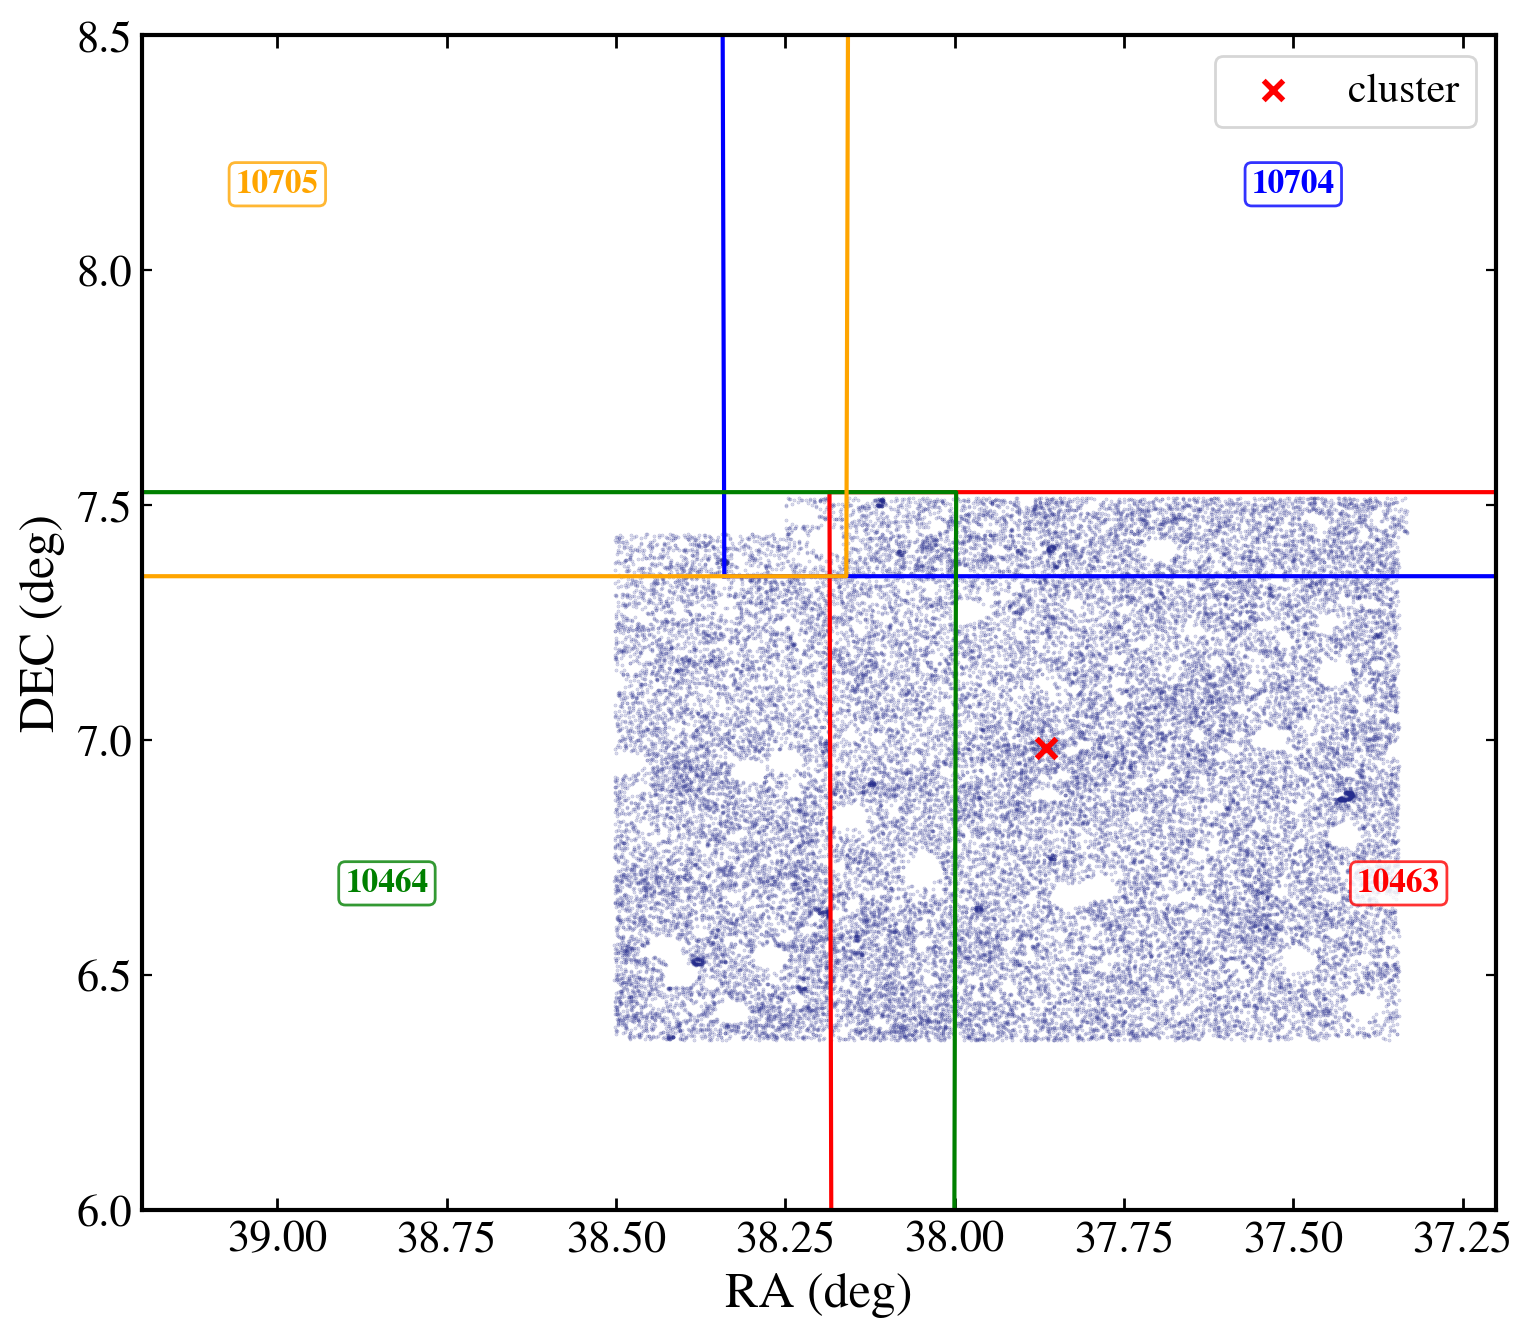

In [9]:
# Apply quality and color cuts
msk = np.logical_and.reduce((
    anacal_table["is_primary"],
    anacal_table["mask_value"] < 40,
    anacal_table["wsel"] > 1e-5,
    anacal_table["z_mag"] < 25.5,
    anacal_table["i_mag"] < 24.0,
    anacal_table["r_mag"] < 25.5,
    anacal_table["g_mag"] < 25.5,
    (anacal_table["i_fpfs1_m00"] + anacal_table["i_fpfs1_m20"]) / anacal_table["i_fpfs1_m00"]  > 0.1,
    ~(counts >= 3),
))
print(f"Before cuts: {len(anacal_table)}")
print(f"After cuts:  {np.sum(msk)}")
anacal_table = anacal_table[msk]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(anacal_table["ra"], anacal_table["dec"], s=0.1, alpha=0.3)
ax.scatter(ra_bcg, dec_bcg, s=50, c='red', marker='x', zorder=10, label='cluster')

# Tract boundaries
tract_ids = [10463, 10704, 10464, 10705]
colors = ['red', 'blue', 'green', 'orange']
for tid, color in zip(tract_ids, colors):
    try:
        ti = t_skymap[tid]
        wcs = ti.getWcs()
        bb = ti.getBBox()
        corners = [(bb.getMinX(), bb.getMinY()), (bb.getMaxX(), bb.getMinY()),
                    (bb.getMaxX(), bb.getMaxY()), (bb.getMinX(), bb.getMaxY()),
                    (bb.getMinX(), bb.getMinY())]
        ra_c = [wcs.pixelToSky(Point2D(x, y)).getRa().asDegrees() for x, y in corners]
        dec_c = [wcs.pixelToSky(Point2D(x, y)).getDec().asDegrees() for x, y in corners]
        ax.plot(ra_c, dec_c, '-', color=color, lw=1.5)
        cen = wcs.pixelToSky(Point2D((bb.getMinX()+bb.getMaxX())/2, (bb.getMinY()+bb.getMaxY())/2))
        ax.text(cen.getRa().asDegrees(), cen.getDec().asDegrees(), str(tid),
                color=color, fontsize=12, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))
    except Exception:
        pass

ax.set_xlabel('RA (deg)'); ax.set_ylabel('DEC (deg)')
ax.set_xlim(37.2, 39.2)
ax.set_ylim(6, 8.5)
ax.legend(loc='upper right', fontsize=15)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 6. Shear Estimation

In [10]:
# C0 scaled by mag_zero
c0_base = 8.4
ratio = 10.0 ** ((mag_zero - 30.0) / 2.5)
c0 = c0_base * ratio
print(f"C0 = {c0_base} * {ratio:.4f} = {c0:.4f}")

# Weighted shapelet moments
m22c = np.zeros(len(anacal_table))
dm22c_dg1 = np.zeros(len(anacal_table))
m22s = np.zeros(len(anacal_table))
dm22s_dg2 = np.zeros(len(anacal_table))
m00 = np.zeros(len(anacal_table))
dm00_dg1 = np.zeros(len(anacal_table))
dm00_dg2 = np.zeros(len(anacal_table))
for band, w in zip(["g", "r", "i", "z"], wlist):
    m22c += anacal_table[f"{band}_fpfs1_m22c"] * w
    m22s += anacal_table[f"{band}_fpfs1_m22s"] * w
    m00  += anacal_table[f"{band}_fpfs1_m00"] * w
    dm22c_dg1 += anacal_table[f"{band}_fpfs1_dm22c_dg1"] * w
    dm22s_dg2 += anacal_table[f"{band}_fpfs1_dm22s_dg2"] * w
    dm00_dg1  += anacal_table[f"{band}_fpfs1_dm00_dg1"] * w
    dm00_dg2  += anacal_table[f"{band}_fpfs1_dm00_dg2"] * w

e1 = m22c / (m00 + c0) * anacal_table["wsel"]
e2 = m22s / (m00 + c0) * anacal_table["wsel"]
de1_dg1 = dm22c_dg1 / (m00 + c0) - m22c / (m00 + c0)**2 * dm00_dg1
de2_dg2 = dm22s_dg2 / (m00 + c0) - m22s / (m00 + c0)**2 * dm00_dg2
res = (de1_dg1 * anacal_table["wsel"] + anacal_table["dwsel_dg1"] * m22c / (m00 + c0)
     + de2_dg2 * anacal_table["wsel"] + anacal_table["dwsel_dg2"] * m22s / (m00 + c0)) / 2.0

C0 = 8.4 * 3.6308 = 30.4986


## 7. Tangential Shear Profile

In [11]:
def fast_bootstrap_mean(data, ci_level=0.95):
    from scipy.stats import bootstrap
    data = np.asarray(data)
    res = bootstrap((data,), np.mean, confidence_level=ci_level)
    return np.array([res.confidence_interval.low, res.confidence_interval.high])

def anacal_get_tang_cross(cluster, sky_dist, bins, R, ci_level=0.95):
    nb = len(bins) - 1
    tang_avg, cross_avg = np.zeros(nb), np.zeros(nb)
    tang_err, cross_err = np.zeros((nb, 2)), np.zeros((nb, 2))
    res_avg, res_err = np.zeros(nb), np.zeros((nb, 2))
    R_correction2 = np.mean(R)
    for i in range(nb):
        filt = (sky_dist > bins[i]) & (sky_dist < bins[i+1])
        if np.sum(filt) < 1:
            continue
        sample = cluster[filt]
        sr = R[filt]
        tang_avg[i] = np.mean(sample.real) / R_correction2
        cross_avg[i] = np.mean(sample.imag) / R_correction2
        res_avg[i] = np.mean(sr)
        res_err[i] = fast_bootstrap_mean(sr, ci_level)
        tang_err[i] = fast_bootstrap_mean(sample.real, ci_level) / R_correction2
        cross_err[i] = fast_bootstrap_mean(sample.imag, ci_level) / R_correction2
    return tang_avg, cross_avg, tang_err, cross_err, res_avg, res_err

# Compute tangential/cross shear
source_phi = np.arctan2(anacal_table['dec'] - dec_bcg,
                        (ra_bcg - anacal_table['ra']) * np.cos(np.deg2rad(dec_bcg)))
ang_dist = np.sqrt(((anacal_table['ra'] - ra_bcg) * np.cos(np.deg2rad(dec_bcg)))**2
                   + (anacal_table['dec'] - dec_bcg)**2)
sky_distance = Da(z_cl) * ang_dist * (np.pi / 180)

cl_shear = (e1 + 1j * e2) * -1 * np.exp(-2j * source_phi)
bins_mpc = clmm.make_bins(0.5, 6, nbins=6, method='evenlog10width')
bin_mids = 0.5 * (bins_mpc[1:] + bins_mpc[:-1])
shear_cl = anacal_get_tang_cross(cl_shear, sky_distance, bins_mpc, res, ci_level=0.68)

# NFW model
moo = clmm.Modeling(massdef="critical", delta_mdef=500, halo_profile_model="nfw")
moo.set_cosmo(cosmo); moo.set_concentration(4); moo.set_mass(6e14)
gt_z = moo.eval_reduced_tangential_shear(
    rproj, z_cl, [beta_s_mean, beta_s_square_mean], z_src_info="beta", approx="order2")

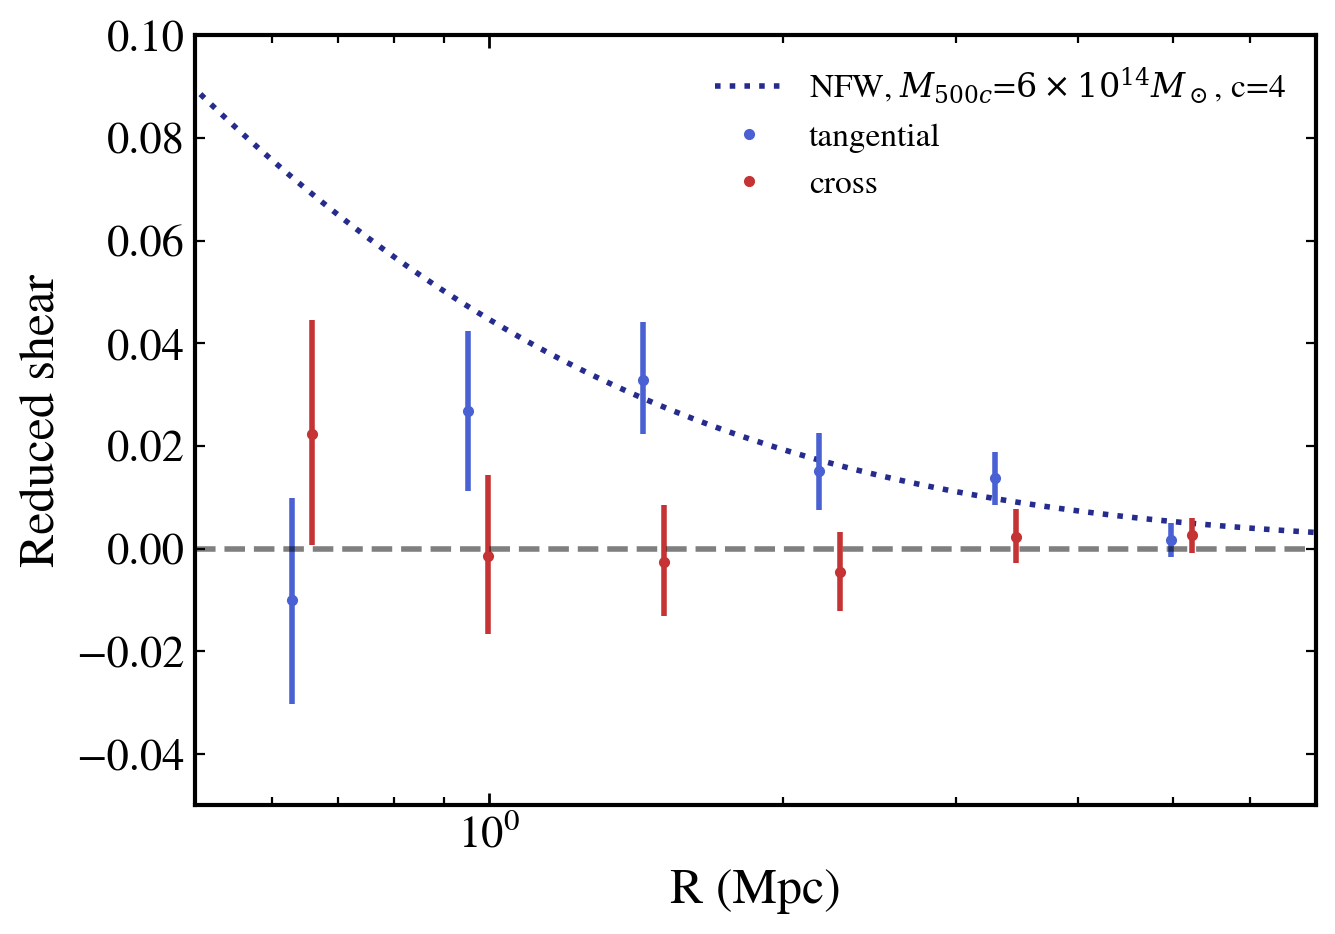

In [12]:
cmap = cm.coolwarm
plt.figure(figsize=(7, 5))
plt.plot(rproj, gt_z, label=r'NFW, $M_{500c}$=$6\times10^{14} M_\odot$, c=4', ls=':')
plt.plot(bin_mids, shear_cl[0], '.', label='tangential', color=cmap(0.05))
plt.vlines(bin_mids, shear_cl[2][:, 0], shear_cl[2][:, 1], color=cmap(0.05))
plt.plot(1.05 * bin_mids, shear_cl[1], '.', label='cross', color=cmap(0.95))
plt.vlines(1.05 * bin_mids, shear_cl[3][:, 0], shear_cl[3][:, 1], color=cmap(0.95))
plt.semilogx(); plt.axhline(0, ls='--', color='k', alpha=0.5)
plt.ylim(-0.05, 0.10); plt.xlim(0.5, 7)
plt.ylabel("Reduced shear"); plt.xlabel("R (Mpc)")
plt.legend(frameon=False, loc='upper right', fontsize=12)
plt.tight_layout(); plt.show()

## 8. Mass Map

In [13]:
def schirmer_filter(radius, aperture_size=8000, x_cut=0.15, a=15, b=150, c=47, d=50, *_):
    x = radius / aperture_size
    return (1 / (1 + np.exp(a - b*x) + np.exp(-c + d*x))) * (np.tanh(x/x_cut) / (x/x_cut))

def compute_mass_map(x_grid, y_grid, x, y, g1, g2, weights, q_filter, filter_kwargs={}):
    y_shape, x_shape = len(y_grid[:, 0]), len(x_grid[0, :])
    Map_E = np.zeros((y_shape, x_shape))
    Map_B = np.zeros((y_shape, x_shape))
    Map_V = np.zeros((y_shape, x_shape))
    filter_area = np.pi * filter_kwargs.get('aperture_size', 0.55)**2
    comp_shear = g1 + 1j * g2
    g_mag = g1**2 + g2**2
    weight_sum = np.sum(weights)
    for i in range(y_shape):
        for j in range(x_shape):
            dx, dy = x - x_grid[j, i], y - y_grid[j, i]
            radius = np.sqrt(dx**2 + dy**2)
            theta = np.arctan2(dy, dx)
            rot = comp_shear * -1 * np.exp(-2j * theta)
            fv = q_filter(radius, **filter_kwargs)
            Map_E[i, j] = np.sum(fv * rot.real * weights) * filter_area / weight_sum
            Map_B[i, j] = np.sum(fv * rot.imag * weights) * filter_area / weight_sum
            Map_V[i, j] = np.sum(fv**2 * g_mag * weights**2) * filter_area**2 / (2 * weight_sum**2)
    return Map_E, Map_B, Map_V

In [14]:
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord

flat_wcs = WCS(naxis=2)
flat_wcs.wcs.crval = [ra_bcg, dec_bcg]
flat_wcs.wcs.crpix = [0, 0]
flat_wcs.wcs.cd = [[-0.2/3600, 0], [0, 0.2/3600]]
flat_wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
flat_wcs.wcs.radesys, flat_wcs.wcs.equinox = 'ICRS', 2000

coords = SkyCoord(ra=anacal_table['ra'], dec=anacal_table['dec'], unit='degree')
x_sky, y_sky = skycoord_to_pixel(coords, wcs=flat_wcs)
x_sky, y_sky = x_sky * 0.2 / 3600, y_sky * 0.2 / 3600

N = 121
x_samples = np.linspace(-0.5, 0.5, N)
y_samples = np.linspace(-0.5, 0.5, N)
y_grid, x_grid = np.meshgrid(y_samples, x_samples)

global_R = np.mean(res)
print(f"Mean shear response: {global_R:.4f}")
g1 = e1 / global_R
g2 = e2 / global_R
w_map = np.ones(len(x_sky))

Mean shear response: 0.4107


In [15]:
e_ap, b_ap, v_ap = compute_mass_map(
    x_grid, y_grid, x_sky, y_sky, g1, g2, w_map,
    schirmer_filter, filter_kwargs={'aperture_size': 0.4})

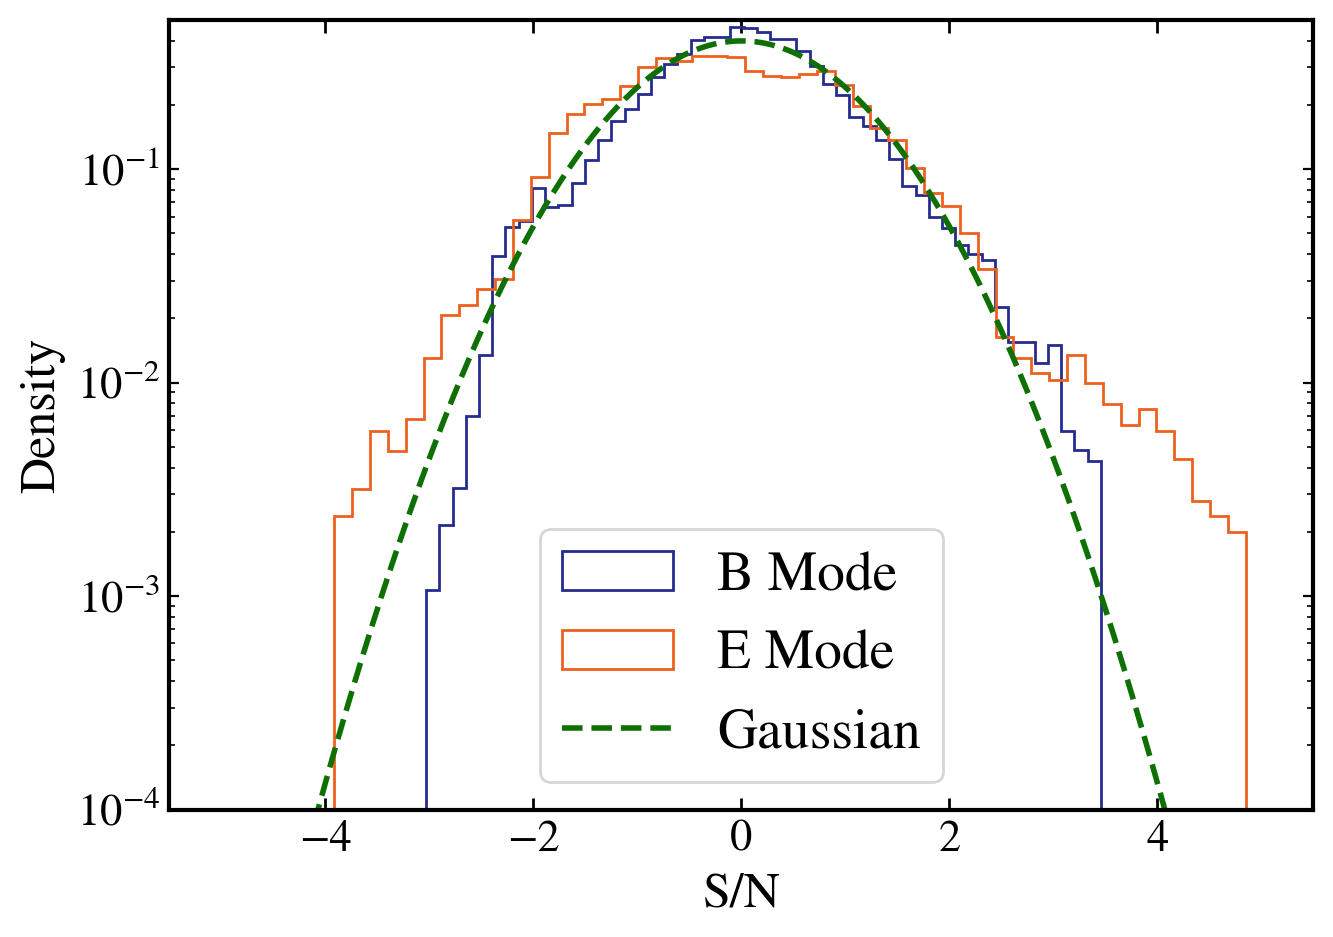

In [16]:
# S/N histograms
b_sn = (b_ap / np.sqrt(v_ap)).flatten()
e_sn = (e_ap / np.sqrt(v_ap)).flatten()
test_xs = np.linspace(-5, 5, 1001)

plt.figure(figsize=(7, 5))
plt.hist(b_sn[np.isfinite(b_sn)], bins=51, label='B Mode', histtype='step', density=True)
plt.hist(e_sn[np.isfinite(e_sn)], bins=51, label='E Mode', histtype='step', density=True)
plt.plot(test_xs, stats.norm.pdf(test_xs), '--', label='Gaussian')
plt.legend(); plt.yscale("log"); plt.ylim(1e-4, 5e-1)
plt.xlabel("S/N"); plt.ylabel("Density")
plt.tight_layout(); plt.show()

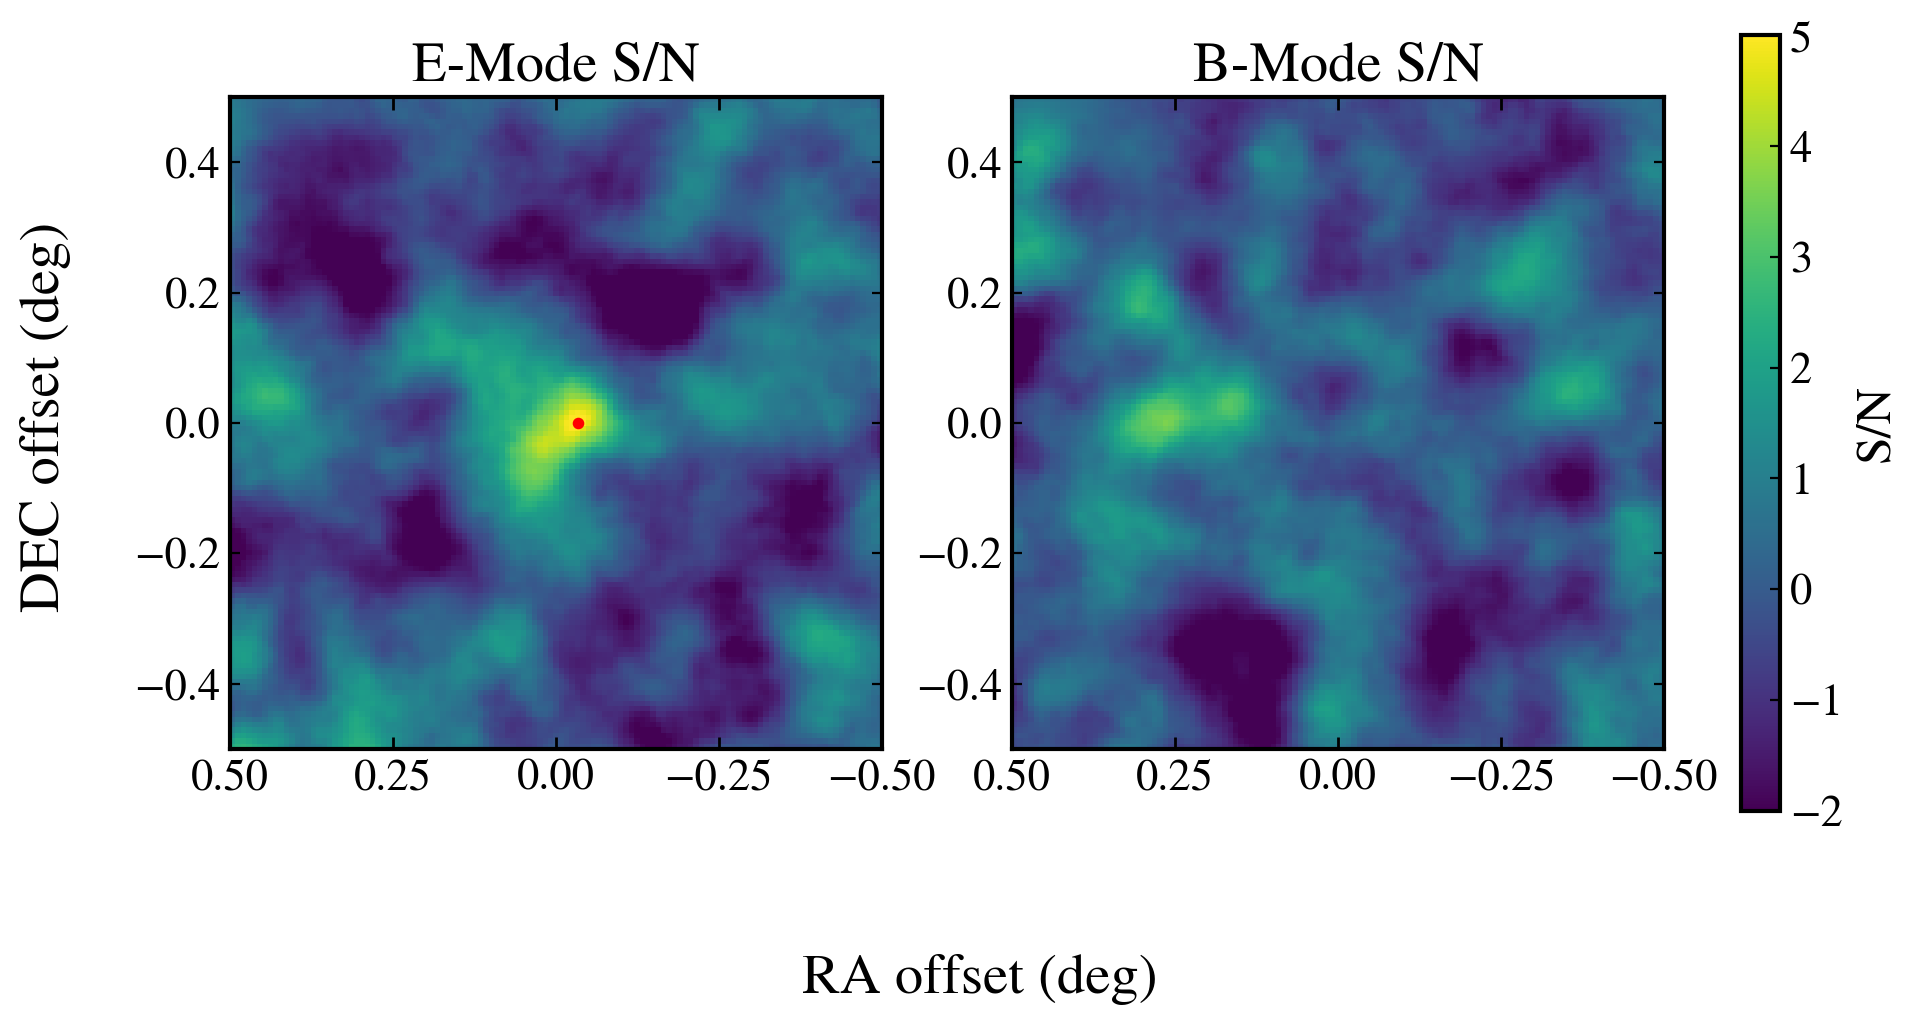

E-mode peak S/N: 5.25
B-mode peak S/N: 3.61


In [17]:
# E/B mode maps
e_sn_map = e_ap / np.sqrt(np.nanmean(v_ap))
b_sn_map = b_ap / np.sqrt(np.nanmean(v_ap))
extent = (0.5, -0.5, -0.5, 0.5)

fig, axs = plt.subplots(ncols=2, figsize=(10, 6))
for ax, data, title in zip(axs, [e_sn_map, b_sn_map], ['E-Mode S/N', 'B-Mode S/N']):
    im = ax.imshow(data, vmin=-2, vmax=5, origin='lower', extent=extent)
    ax.set_title(title)
# Mark E-mode peak
iy, ix = np.unravel_index(np.nanargmax(e_sn_map), e_sn_map.shape)
x_vals, y_vals = np.linspace(extent[0], extent[1], N), np.linspace(extent[2], extent[3], N)
axs[0].scatter(x_vals[ix], y_vals[iy], s=10, color="red")

fig.colorbar(im, ax=axs, fraction=0.025, label="S/N")
fig.supxlabel("RA offset (deg)"); fig.supylabel("DEC offset (deg)")
plt.show()

print(f"E-mode peak S/N: {np.nanmax(e_sn_map):.2f}")
print(f"B-mode peak S/N: {np.nanmax(b_sn_map):.2f}")